<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [7]:
# Install the necessary libraries
!pip install pandas
!pip install matplotlib
!pip install seaborn


In [9]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2: Load the Dataset


In [11]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert to numeric and drop missing
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
comp_df = df['ConvertedCompYearly'].dropna()


<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [15]:
# Filter only full-time employed respondents
full_time_df = df[df['Employment'] == 'Employed, full-time']

# Drop missing compensation values
full_time_comp = pd.to_numeric(full_time_df['ConvertedCompYearly'], errors='coerce').dropna()


In [16]:
median_comp_full_time = full_time_comp.median()
print(f"Median yearly compensation for full-time employees: ${median_comp_full_time:,.2f}")


Median yearly compensation for full-time employees: $69,814.00


<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure numeric and drop missing compensation
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
comp_country_df = df[['Country', 'ConvertedCompYearly']].dropna()


<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


In [20]:
# Use numeric and drop missing values
comp_series = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce').dropna()

# Calculate Q1 and Q3
Q1 = comp_series.quantile(0.25)
Q3 = comp_series.quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound: ${lower_bound:,.2f}, Upper bound: ${upper_bound:,.2f}")


Lower bound: $-80,177.25, Upper bound: $220,860.75


In [21]:
# Keep only rows within the IQR bounds
df_no_outliers = df[(df['ConvertedCompYearly'] >= lower_bound) & (df['ConvertedCompYearly'] <= upper_bound)]

print(f"Original dataset size: {df.shape[0]} rows")
print(f"Dataset size after removing outliers: {df_no_outliers.shape[0]} rows")


Original dataset size: 65437 rows
Dataset size after removing outliers: 22457 rows


<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure numeric and drop missing
df_no_outliers['ConvertedCompYearly'] = pd.to_numeric(df_no_outliers['ConvertedCompYearly'], errors='coerce')
df_no_outliers['YearsCodePro'] = pd.to_numeric(df_no_outliers['YearsCodePro'], errors='coerce')
df_no_outliers['JobSatPoints_1'] = pd.to_numeric(df_no_outliers['JobSatPoints_1'], errors='coerce')

# Select columns of interest and drop rows with missing values
corr_df = df_no_outliers[['ConvertedCompYearly', 'YearsCodePro', 'JobSatPoints_1']].dropna()


/tmp/ipykernel_386/3512658911.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers['ConvertedCompYearly'] = pd.to_numeric(df_no_outliers['ConvertedCompYearly'], errors='coerce')
/tmp/ipykernel_386/3512658911.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers['YearsCodePro'] = pd.to_numeric(df_no_outliers['YearsCodePro'], errors='coerce')
/tmp/ipykernel_386/3512658911.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc

In [23]:
corr_matrix = corr_df.corr()
print("Correlation matrix:")
print(corr_matrix)


Correlation matrix:
                     ConvertedCompYearly  YearsCodePro  JobSatPoints_1
ConvertedCompYearly             1.000000      0.400606       -0.062890
YearsCodePro                    0.400606      1.000000       -0.037566
JobSatPoints_1                 -0.062890     -0.037566        1.000000


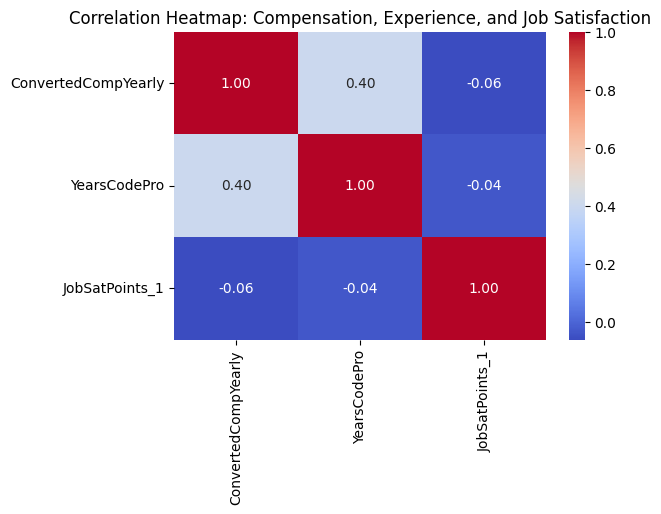

In [24]:
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap: Compensation, Experience, and Job Satisfaction")
plt.show()


<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure numeric and drop missing values
scatter_df = df_no_outliers[['ConvertedCompYearly', 'YearsCodePro', 'JobSatPoints_1']].dropna()


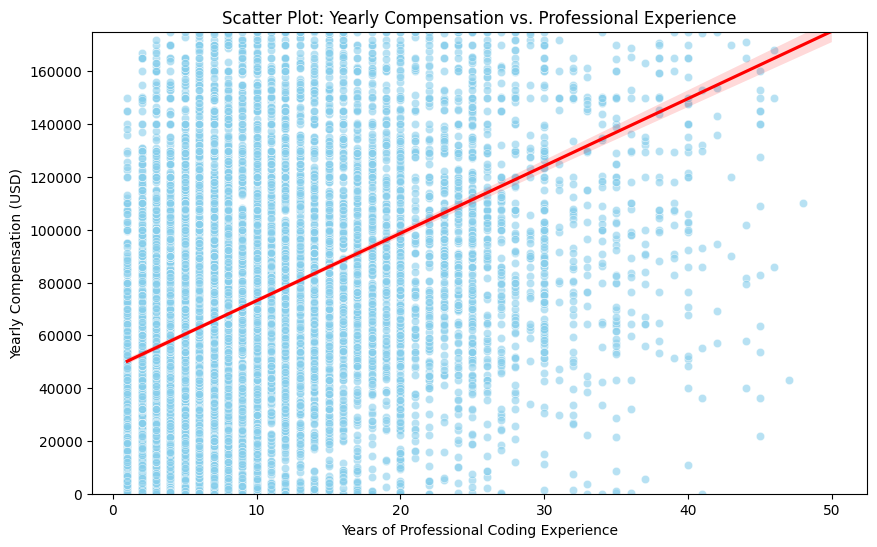

In [26]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='YearsCodePro', y='ConvertedCompYearly', data=scatter_df, alpha=0.6, color='skyblue')
sns.regplot(x='YearsCodePro', y='ConvertedCompYearly', data=scatter_df, scatter=False, color='red')
plt.title("Scatter Plot: Yearly Compensation vs. Professional Experience")
plt.xlabel("Years of Professional Coding Experience")
plt.ylabel("Yearly Compensation (USD)")
plt.ylim(0, scatter_df['ConvertedCompYearly'].quantile(0.95))  # limit top 5% for better visualization
plt.show()


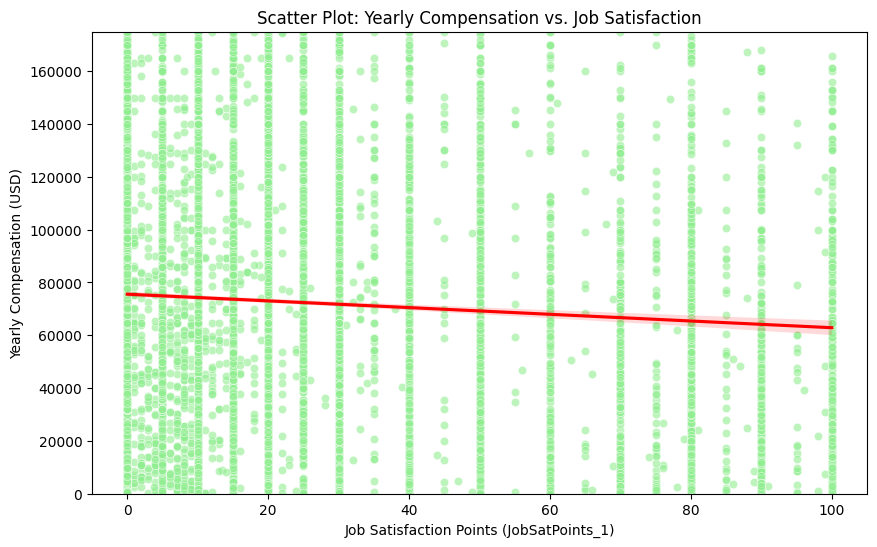

In [27]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='JobSatPoints_1', y='ConvertedCompYearly', data=scatter_df, alpha=0.6, color='lightgreen')
sns.regplot(x='JobSatPoints_1', y='ConvertedCompYearly', data=scatter_df, scatter=False, color='red')
plt.title("Scatter Plot: Yearly Compensation vs. Job Satisfaction")
plt.xlabel("Job Satisfaction Points (JobSatPoints_1)")
plt.ylabel("Yearly Compensation (USD)")
plt.ylim(0, scatter_df['ConvertedCompYearly'].quantile(0.95))  # limit top 5% for better visualization
plt.show()


<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
